In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, hard_threshold:float=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)

        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))

        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f"x debe ser (B, {self.in_features})")

        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)

        gate = gate_hard - gate_soft.detach() + gate_soft

        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    @torch.no_grad()
    def gate_soft(self) -> torch.Tensor:
        return torch.sigmoid(self.logits / self.temperature)

    def sparsity_loss(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return gate_soft.mean()

    @torch.no_grad()
    def hard_mask(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return (gate_soft > self.hard_threshold)

class VAE(nn.Module):
    def __init__(self, input_dim, output_dim, latent_dim=128):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.fc1 = LearnedSparseLinear(input_dim, 400)
        self.fc21 = LearnedSparseLinear(400, latent_dim)
        self.fc22 = LearnedSparseLinear(400, latent_dim)
        self.fc3 = LearnedSparseLinear(latent_dim, 400)
        self.fc4 = LearnedSparseLinear(400, output_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

class DeMemte(nn.Module):
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone 
        self.vae = vae           
        
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            raw_features = self.backbone(x)
        features = self.feat_norm(raw_features)
        
        x_rec, mu, logvar = self.vae(features)
        
        recon_diff = (features - x_rec)**2
        recon_loss_per_sample = torch.mean(recon_diff, dim=1, keepdim=True)
        
        gamma = F.softplus(self.signal_gamma) 
        signal = torch.exp(-recon_loss_per_sample * gamma)
        
        enhanced_features = features + (self.memory_scale * signal * x_rec)
        logits = self.classifier(enhanced_features)
        
        return logits, x_rec, mu, logvar, features

    def train(self, mode: bool = True):
        super().train(mode)
        self.backbone.eval()
        return self

In [6]:
# Transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

batch_size = 64

# CIFAR-10
trainset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=batch_size, shuffle=True, num_workers=2)

testset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=batch_size, shuffle=False, num_workers=2)

# Flowers102
trainset_flowers = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform_train)
trainloader_flowers = torch.utils.data.DataLoader(trainset_flowers, batch_size=batch_size, shuffle=True, num_workers=2)

testset_flowers = torchvision.datasets.Flowers102(root='./data', split='test', download=True, transform=transform_test)
testloader_flowers = torch.utils.data.DataLoader(testset_flowers, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"CIFAR-10 Train: {len(trainset_cifar)}, Test: {len(testset_cifar)}")
print(f"Flowers102 Train: {len(trainset_flowers)}, Test: {len(testset_flowers)}")

/home/nakato/projects/Dmente/env/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 Train: 50000, Test: 10000
Flowers102 Train: 1020, Test: 6149


In [7]:
# Define Baseline ResNet-18
def get_resnet_baseline(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

baseline_cifar = get_resnet_baseline(10)

criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(baseline_cifar.fc.parameters(), lr=0.001)

epochs_cifar = 5 # Keep it short for demonstration, adjust as needed
baseline_cifar_history = {'loss': [], 'acc': []}

print("Training Baseline ResNet-18 on CIFAR-10...")
for epoch in range(epochs_cifar):
    baseline_cifar.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, data in enumerate(trainloader_cifar, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        
        optimizer_baseline.zero_grad()
        outputs = baseline_cifar(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_baseline.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(trainloader_cifar)
    epoch_acc = 100 * correct / total
    baseline_cifar_history['loss'].append(epoch_loss)
    baseline_cifar_history['acc'].append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs_cifar} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

print("Finished Training Baseline on CIFAR-10")

Training Baseline ResNet-18 on CIFAR-10...
Epoch 1/5 - Loss: 0.8231, Acc: 73.31%
Epoch 2/5 - Loss: 0.6213, Acc: 78.72%
Epoch 3/5 - Loss: 0.5931, Acc: 79.62%
Epoch 4/5 - Loss: 0.5841, Acc: 79.75%
Epoch 5/5 - Loss: 0.5702, Acc: 80.25%
Finished Training Baseline on CIFAR-10


In [12]:
# Build and train DeMemte on CIFAR-10 (no checkpoint loading)
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
backbone = torch.nn.Sequential(*list(base_model.children())[:-1], torch.nn.Flatten())
for p in backbone.parameters():
    p.requires_grad = False
backbone.eval()

embedding_dim = 512
num_classes_cifar = 10
latent_dim = 128

memoria_vae = VAE(input_dim=embedding_dim, output_dim=embedding_dim, latent_dim=latent_dim)
dememte_cifar = DeMemte(
    backbone=backbone,
    vae=memoria_vae,
    embedding_dim=embedding_dim,
    num_classes=num_classes_cifar
).to(device)

def dememte_loss_cifar(logits, labels, x_rec, features, mu, logvar, model, sparsity_weight=0.01):
    task_loss = F.cross_entropy(logits, labels)
    recon_loss = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    vae_loss = recon_loss + kld_loss

    sparsity_loss = 0.0
    for module in model.modules():
        if isinstance(module, LearnedSparseLinear):
            sparsity_loss += module.sparsity_loss()

    total_loss = task_loss + 0.1 * vae_loss + sparsity_weight * sparsity_loss
    return total_loss

# Train DeMemte on CIFAR-10
epochs_dememte_cifar = epochs_cifar
optimizer_dememte_cifar = optim.Adam([
    {'params': dememte_cifar.vae.parameters(), 'lr': 1e-4},
    {'params': dememte_cifar.classifier.parameters(), 'lr': 1e-3},
    {'params': [dememte_cifar.signal_gamma, dememte_cifar.memory_scale], 'lr': 1e-3}
])

dememte_cifar_history = {'loss': [], 'acc': []}

print("Training DeMemte on CIFAR-10...")
for epoch in range(epochs_dememte_cifar):
    dememte_cifar.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Optional light temperature annealing for sparse gates
    new_temp = max(0.3, 1.0 - 0.1 * epoch)
    for module in dememte_cifar.modules():
        if isinstance(module, LearnedSparseLinear):
            module.temperature = new_temp

    for data in trainloader_cifar:
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer_dememte_cifar.zero_grad()
        logits, x_rec, mu, logvar, features = dememte_cifar(inputs)
        loss = dememte_loss_cifar(logits, labels, x_rec, features, mu, logvar, dememte_cifar)
        loss.backward()
        optimizer_dememte_cifar.step()

        running_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader_cifar)
    epoch_acc = 100 * correct / total
    dememte_cifar_history['loss'].append(epoch_loss)
    dememte_cifar_history['acc'].append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs_dememte_cifar} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

# Evaluation function
def evaluate_model(model, testloader, is_dememte=False):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            if is_dememte:
                outputs, _, _, _, _ = model(inputs)
            else:
                outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

print("Evaluating on CIFAR-10 Test Set...")
acc_baseline_cifar = evaluate_model(baseline_cifar, testloader_cifar)
acc_dememte_cifar = evaluate_model(dememte_cifar, testloader_cifar, is_dememte=True)

print(f"Baseline ResNet-18 CIFAR-10 Accuracy: {acc_baseline_cifar:.2f}%")
print(f"Dememte CIFAR-10 Accuracy (trained in notebook): {acc_dememte_cifar:.2f}%")

Training DeMemte on CIFAR-10...
Epoch 1/5 - Loss: 30.3160, Acc: 81.11%
Epoch 2/5 - Loss: 22.5174, Acc: 86.13%
Epoch 3/5 - Loss: 20.8083, Acc: 86.83%
Epoch 4/5 - Loss: 19.6943, Acc: 87.28%
Epoch 5/5 - Loss: 18.9430, Acc: 87.57%
Evaluating on CIFAR-10 Test Set...
Baseline ResNet-18 CIFAR-10 Accuracy: 79.73%
Dememte CIFAR-10 Accuracy (trained in notebook): 86.43%


In [13]:
num_classes_flowers = 102

def load_compatible_weights(target_model, source_state_dict):
    target_state = target_model.state_dict()
    compatible = {}
    skipped = []

    for key, value in source_state_dict.items():
        if key in target_state and target_state[key].shape == value.shape:
            compatible[key] = value
        else:
            skipped.append(key)

    target_state.update(compatible)
    target_model.load_state_dict(target_state)
    return len(compatible), len(skipped)

# 1. Prepare Baseline for Flowers102
baseline_flowers = get_resnet_baseline(num_classes_flowers)
loaded_count, skipped_count = load_compatible_weights(baseline_flowers, baseline_cifar.state_dict())
baseline_flowers = baseline_flowers.to(device)
print(f"Baseline transfer -> loaded: {loaded_count}, skipped: {skipped_count} (expected skip: fc.*)")

# 2. Prepare Dememte for Flowers102
# Keep backbone + VAE memory from CIFAR-10 and adapt classifier to 102 classes
dememte_flowers = DeMemte(backbone=backbone, vae=memoria_vae, embedding_dim=embedding_dim, num_classes=num_classes_flowers).to(device)
loaded_count, skipped_count = load_compatible_weights(dememte_flowers, dememte_cifar.state_dict())
print(f"DeMemte transfer -> loaded: {loaded_count}, skipped: {skipped_count} (expected skip: classifier.*)")

print("Models prepared for Flowers102 fine-tuning.")

Baseline transfer -> loaded: 120, skipped: 2 (expected skip: fc.*)
DeMemte transfer -> loaded: 139, skipped: 3 (expected skip: classifier.*)
Models prepared for Flowers102 fine-tuning.


In [14]:
optimizer_baseline_ft = optim.Adam(baseline_flowers.fc.parameters(), lr=0.001)
epochs_ft = 10

baseline_ft_history = {'loss': [], 'acc': []}

print("Fine-tuning Baseline ResNet-18 on Flowers102...")
for epoch in range(epochs_ft):
    baseline_flowers.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, data in enumerate(trainloader_flowers, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        
        optimizer_baseline_ft.zero_grad()
        outputs = baseline_flowers(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_baseline_ft.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(trainloader_flowers)
    epoch_acc = 100 * correct / total
    baseline_ft_history['loss'].append(epoch_loss)
    baseline_ft_history['acc'].append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs_ft} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

print("Finished Fine-tuning Baseline on Flowers102")

Fine-tuning Baseline ResNet-18 on Flowers102...
Epoch 1/10 - Loss: 4.7286, Acc: 2.75%
Epoch 2/10 - Loss: 3.7277, Acc: 27.84%
Epoch 3/10 - Loss: 2.9412, Acc: 60.00%
Epoch 4/10 - Loss: 2.3075, Acc: 76.96%
Epoch 5/10 - Loss: 1.8067, Acc: 86.08%
Epoch 6/10 - Loss: 1.4267, Acc: 92.84%
Epoch 7/10 - Loss: 1.1461, Acc: 93.82%
Epoch 8/10 - Loss: 0.9371, Acc: 95.49%
Epoch 9/10 - Loss: 0.7671, Acc: 97.35%
Epoch 10/10 - Loss: 0.6490, Acc: 97.94%
Finished Fine-tuning Baseline on Flowers102


In [15]:
# Dememte Loss Function
def dememte_loss(logits, labels, x_rec, features, mu, logvar, model, sparsity_weight=0.01):
    # Task Loss
    task_loss = F.cross_entropy(logits, labels)
    
    # VAE Loss
    recon_loss = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    vae_loss = recon_loss + kld_loss
    
    # Sparsity Loss
    s_loss = 0.0
    for module in model.modules():
        if isinstance(module, LearnedSparseLinear):
            s_loss += module.sparsity_loss()
            
    total_loss = task_loss + 0.1 * vae_loss + sparsity_weight * s_loss
    return total_loss, task_loss, vae_loss, s_loss

# Optimizer for Dememte (train VAE and classifier)
optimizer_dememte_ft = optim.Adam([
    {'params': dememte_flowers.vae.parameters(), 'lr': 1e-4},
    {'params': dememte_flowers.classifier.parameters(), 'lr': 1e-3},
    {'params': [dememte_flowers.signal_gamma, dememte_flowers.memory_scale], 'lr': 1e-3}
])

dememte_ft_history = {'loss': [], 'acc': []}

print("Fine-tuning Dememte on Flowers102...")
for epoch in range(epochs_ft):
    dememte_flowers.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, data in enumerate(trainloader_flowers, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        
        optimizer_dememte_ft.zero_grad()
        logits, x_rec, mu, logvar, features = dememte_flowers(inputs)
        
        loss, t_loss, v_loss, s_loss = dememte_loss(logits, labels, x_rec, features, mu, logvar, dememte_flowers)
        
        loss.backward()
        optimizer_dememte_ft.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(trainloader_flowers)
    epoch_acc = 100 * correct / total
    dememte_ft_history['loss'].append(epoch_loss)
    dememte_ft_history['acc'].append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs_ft} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

print("Finished Fine-tuning Dememte on Flowers102")

Fine-tuning Dememte on Flowers102...
Epoch 1/10 - Loss: 58.2300, Acc: 6.67%
Epoch 2/10 - Loss: 52.1035, Acc: 37.94%
Epoch 3/10 - Loss: 48.2775, Acc: 66.96%
Epoch 4/10 - Loss: 45.4111, Acc: 77.25%
Epoch 5/10 - Loss: 43.1601, Acc: 83.14%
Epoch 6/10 - Loss: 41.1637, Acc: 87.55%
Epoch 7/10 - Loss: 39.3866, Acc: 90.69%
Epoch 8/10 - Loss: 37.9153, Acc: 91.57%
Epoch 9/10 - Loss: 36.6040, Acc: 93.73%
Epoch 10/10 - Loss: 35.2946, Acc: 95.00%
Finished Fine-tuning Dememte on Flowers102


Examples from Flowers102 Training Set:


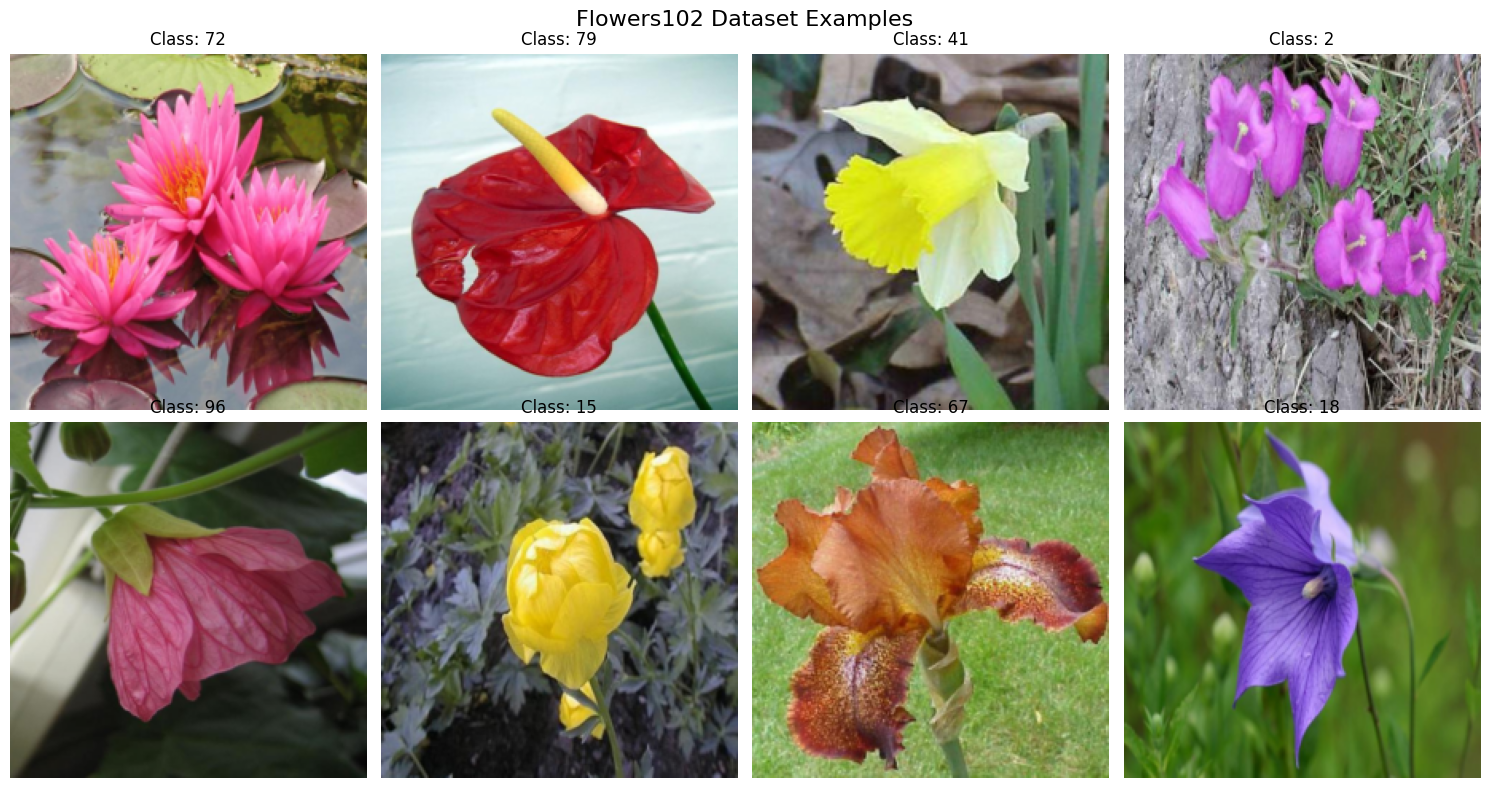


Examples from Flowers102 Test Set:


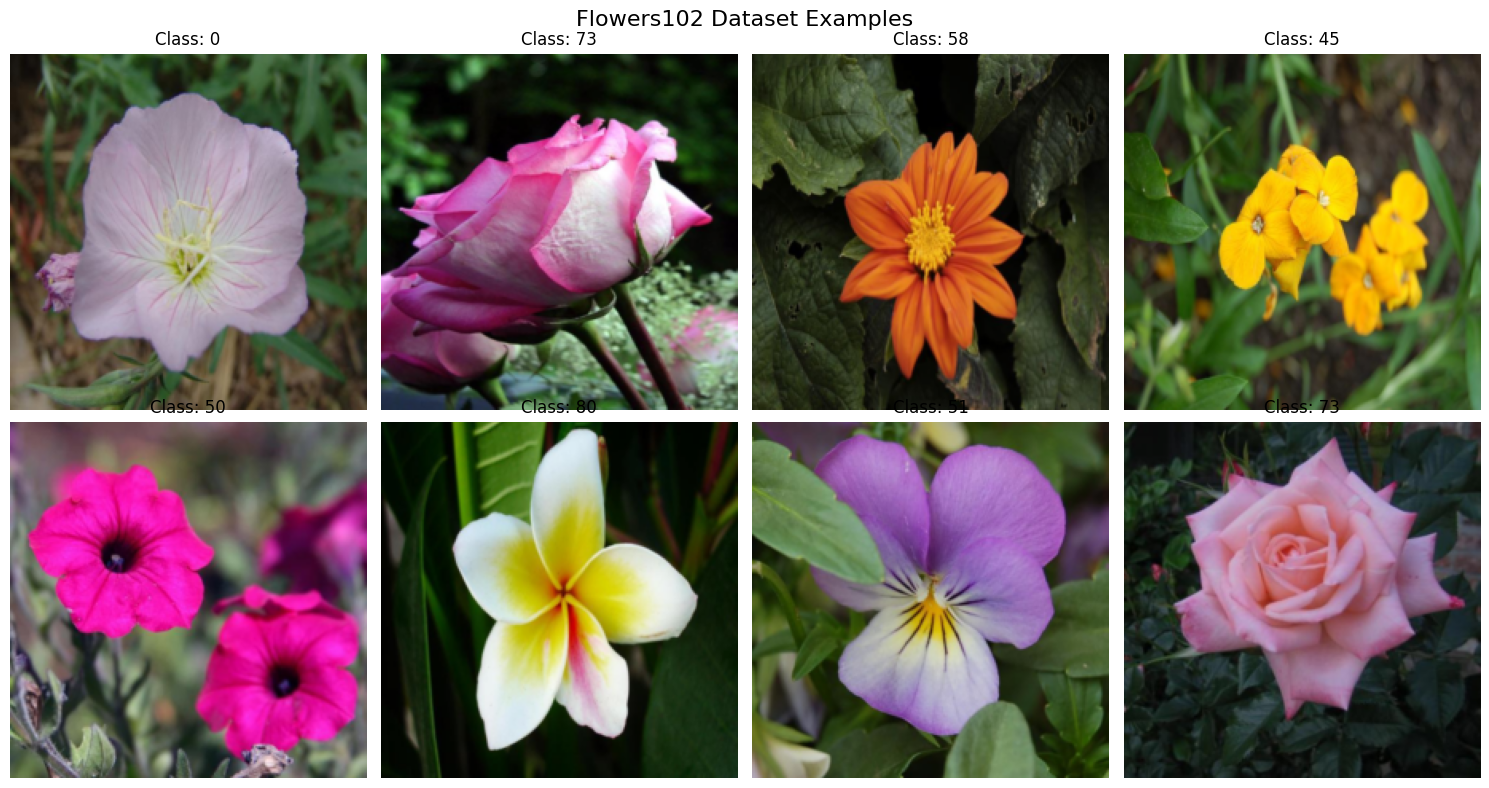

In [17]:
# Display some example images from the Flowers102 dataset
def show_flowers_examples(dataset, num_images=8):
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()
    
    # Get random samples
    indices = np.random.choice(len(dataset), num_images, replace=False)
    
    for idx, ax in enumerate(axes):
        image, label = dataset[indices[idx]]
        
        # Denormalize the image
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = image.numpy().transpose(1, 2, 0)
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1)
        
        ax.imshow(image_np)
        ax.set_title(f'Class: {label}')
        ax.axis('off')
    
    plt.suptitle('Flowers102 Dataset Examples', fontsize=16)
    plt.tight_layout()
    plt.show()

# Show examples from training set
print("Examples from Flowers102 Training Set:")
show_flowers_examples(trainset_flowers)

# Show examples from test set
print("\nExamples from Flowers102 Test Set:")
show_flowers_examples(testset_flowers)

Evaluating on Flowers102 Test Set...
Baseline ResNet-18 Flowers102 Accuracy: 78.68%
Dememte Flowers102 Accuracy: 75.28%


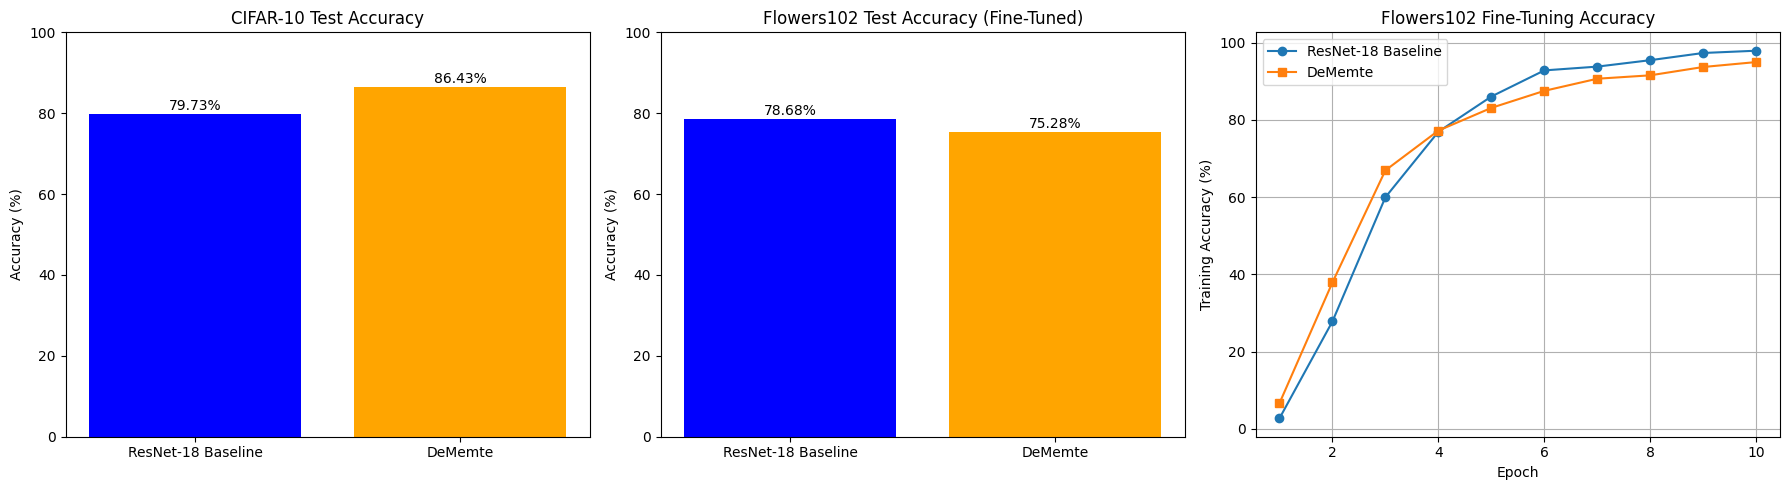

In [16]:
print("Evaluating on Flowers102 Test Set...")
acc_baseline_flowers = evaluate_model(baseline_flowers, testloader_flowers)
acc_dememte_flowers = evaluate_model(dememte_flowers, testloader_flowers, is_dememte=True)

print(f"Baseline ResNet-18 Flowers102 Accuracy: {acc_baseline_flowers:.2f}%")
print(f"Dememte Flowers102 Accuracy: {acc_dememte_flowers:.2f}%")

# Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. CIFAR-10 Comparison
labels = ['ResNet-18 Baseline', 'DeMemte']
cifar_accs = [acc_baseline_cifar, acc_dememte_cifar]
axs[0].bar(labels, cifar_accs, color=['blue', 'orange'])
axs[0].set_title('CIFAR-10 Test Accuracy')
axs[0].set_ylabel('Accuracy (%)')
axs[0].set_ylim(0, 100)
for i, v in enumerate(cifar_accs):
    axs[0].text(i, v + 1, f"{v:.2f}%", ha='center')

# 2. Flowers102 Comparison
flowers_accs = [acc_baseline_flowers, acc_dememte_flowers]
axs[1].bar(labels, flowers_accs, color=['blue', 'orange'])
axs[1].set_title('Flowers102 Test Accuracy (Fine-Tuned)')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_ylim(0, 100)
for i, v in enumerate(flowers_accs):
    axs[1].text(i, v + 1, f"{v:.2f}%", ha='center')

# 3. Fine-Tuning Training Curves
epochs_range = range(1, epochs_ft + 1)
axs[2].plot(epochs_range, baseline_ft_history['acc'], label='ResNet-18 Baseline', marker='o')
axs[2].plot(epochs_range, dememte_ft_history['acc'], label='DeMemte', marker='s')
axs[2].set_title('Flowers102 Fine-Tuning Accuracy')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Training Accuracy (%)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()